# Eval Analytics

Ноутбук анализирует результаты `app/eval/results`, а именно:

- историю запусков из `summary.json`;
- подробные результаты каждого запуска из `<run_id>/per_question.json`;
- retrieval funnel, context packing loss, MRR, generation scores;
- худшие вопросы для ручного разбора;
- latency и сравнение конфигураций.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 220)
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

## Настройки и загрузка данных

`RUN_ID = None` означает анализ последнего запуска


In [2]:
RUN_ID = None

RETRIEVAL_METRICS = [
    "de_recall_at_5",
    "de_recall_at_10",
    "ee_recall",
    "ce_recall",
    "cploss_rate",
    "mrr",
]
GENERATION_METRICS = ["faithfulness_score", "answer_relevance_score"]
TIMING_COLUMNS = [
    "latency_ms",
    "rewrite_latency_ms",
    "retrieval_latency_ms",
    "generation_latency_ms",
]


def find_results_dir() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, *cwd.parents]

    for base in candidates:
        direct = base / "summary.json"
        if direct.exists() and base.name == "results":
            return base

        nested_paths = [
            base / "services/retriever/app/eval/results",
            base / "app/eval/results",
        ]
        for candidate in nested_paths:
            if (candidate / "summary.json").exists():
                return candidate.resolve()

    raise FileNotFoundError("Не найдена папка app/eval/results с summary.json")


RESULTS_DIR = find_results_dir()
SUMMARY_PATH = RESULTS_DIR / "summary.json"
print(f"RESULTS_DIR = {RESULTS_DIR}")

RESULTS_DIR = /home/dved/EngineeringRAG/services/retriever/app/eval/results


In [3]:
def read_json(path: Path):
    with path.open(encoding="utf-8") as source:
        return json.load(source)


def load_summary() -> tuple[list[dict], pd.DataFrame]:
    runs = read_json(SUMMARY_PATH).get("runs", [])
    rows = []

    for run in runs:
        row = {
            "run_id": run.get("run_id"),
            "created_at": pd.to_datetime(run.get("created_at"), utc=True),
            "questions": run.get("questions"),
        }
        row.update({f"config.{k}": v for k, v in run.get("config", {}).items()})
        row.update(run.get("retrieval", {}))
        row.update(run.get("generation", {}))
        rows.append(row)

    df = pd.DataFrame(rows).sort_values("created_at").reset_index(drop=True)
    return runs, df


def selected_run_id(summary_df: pd.DataFrame, run_id: str | None = None) -> str:
    if summary_df.empty:
        raise ValueError("summary.json не содержит запусков")
    return run_id or str(summary_df.iloc[-1]["run_id"])


runs, summary_df = load_summary()
SELECTED_RUN_ID = selected_run_id(summary_df, RUN_ID)
summary_df

,run_id,created_at,questions,config.index_version,config.search_mode,config.top_k,config.prefetch_k,config.use_rewriter,config.expand_refs,config.ref_depth,config.rewrite_system_prompt,config.compose_system_prompt,config.judge_model,de_recall_at_5,de_recall_at_10,ee_recall,ce_recall,cploss_rate,rrs_rate,mrr,faithfulness_score,answer_relevance_score
0,20260615T105229Z,2026-06-15 10:52:29+00:00,200,current,hybrid,10,40,False,True,1,,,NaN,0.545,0.585,0.600,0.565,0.058333,None,0.457351,NaN,NaN
1,20260615T123730Z,2026-06-15 12:37:30.017631+00:00,200,current,hybrid,10,40,True,True,1,"Ты — ассистент по переформулированию поисковых запросов для системы RAG.Твоя задача: преобразовать вопрос пользователя в точный поисковый запрос,пригодный для векторного поиска по нормативным документам (СП, ГОСТ, СН...",Ты — ассистент по нормативной документации в строительстве.Твоя задача: на основе найденных фрагментов подготовить понятный ответ для пользователя.Правила:- Отвечай только по переданному контексту.- Ничего не выд...,query-rewriter,0.535,0.585,0.595,0.550,0.075630,None,0.438829,0.861892,0.910757


In [4]:
def classify_outcome(row: dict) -> str:
    de10 = row.get("de_recall_at_10") or 0
    ee = row.get("ee_recall") or 0
    ce = row.get("ce_recall") or 0

    if ee == 0:
        return "not_found"
    if de10 == 0 and ee > 0 and ce > 0:
        return "found_by_expansion"
    if ee > 0 and ce == 0:
        return "lost_in_context"
    if de10 > 0 and ce > 0:
        return "found_by_search"
    return "other"


def first_retrieved_field(retrieved: list[dict], field: str):
    if not retrieved:
        return None
    return retrieved[0].get(field)


def question_records(run_id: str) -> list[dict]:
    return read_json(RESULTS_DIR / run_id / "per_question.json")


def load_questions(run_id: str) -> pd.DataFrame:
    rows = []

    for item in question_records(run_id):
        pipeline = item.get("pipeline_result", {})
        retrieval = item.get("retrieval_metrics", {})
        generation = item.get("generation_metrics", {})
        timings = pipeline.get("timings", {})
        retrieved = pipeline.get("retrieved", [])
        context_included = pipeline.get("context_included", [])
        context_excluded = pipeline.get("context_excluded", [])
        expanded = pipeline.get("expanded", [])
        question_id = item.get("question_id")

        row = {
            "run_id": run_id,
            "question_id": question_id,
            "discipline": str(question_id).split("-", maxsplit=1)[0],
            "question": pipeline.get("question"),
            "effective_question": pipeline.get("effective_question"),
            "was_rewritten": pipeline.get("was_rewritten"),
            "answer": pipeline.get("answer"),
            "error": pipeline.get("error") or item.get("error"),
            "retrieved_count": len(retrieved),
            "expanded_count": len(expanded),
            "context_included_count": len(context_included),
            "context_excluded_count": len(context_excluded),
            "first_doc": first_retrieved_field(retrieved, "filename"),
            "first_score": first_retrieved_field(retrieved, "score"),
        }
        row.update(retrieval)
        row.update(generation)
        row.update(timings)
        row["outcome"] = classify_outcome(row)
        rows.append(row)

    return pd.DataFrame(rows)


question_df = load_questions(SELECTED_RUN_ID)
all_question_df = pd.concat(
    [load_questions(str(run_id)) for run_id in summary_df["run_id"]],
    ignore_index=True,
)

print(f"Selected run: {SELECTED_RUN_ID}")
question_df.head()

Selected run: 20260615T123730Z


,run_id,question_id,discipline,question,effective_question,was_rewritten,answer,error,retrieved_count,expanded_count,context_included_count,context_excluded_count,first_doc,first_score,de_recall_at_5,de_recall_at_10,ee_recall,ce_recall,cploss_rate,rrs_rate,reciprocal_rank,faithfulness_score,answer_relevance_score,unsupported_claims,explanation,latency_ms,rewrite_latency_ms,retrieval_latency_ms,generation_latency_ms,outcome
0,20260615T123730Z,АР-001,АР,"Какие покрытия пола подходят при средней интенсивности воздействия воды, минеральных масел и органических растворителей?","Покрытия пола для средней интенсивности воздействия воды, минеральных масел и органических растворителей.",True,"#### Ответ \n1. В средней интенсивности воздействия воды, минеральных масел и органических растворителей подходят защитные полимерные покрытия, такие как наливные (самонивелирующиеся) и высоконаполненные, которые им...",NaN,10,1,8,3,СП 71.13330.2017 Изоляционные и отделочные покрытия. Актуализированная редакция.md,14.512335,0.0,0.0,0.0,0.0,NaN,None,0.000000,0.80,0.90,[],"Ответ основывается на информации из СП 71.13330.2017, где указано, что наливные и высоконаполненные полимерные покрытия подходят для средней интенсивности воздействия воды, минеральных масел и органических растворите...",15700,989,8107,6602,not_found
1,20260615T123730Z,АР-002,АР,Для каких задач нужна система видеоконференцсвязи в медицинской организации?,"Системы видеоконференцсвязи в медицинских организациях применяются для медицинского общения, дистанционного консультирования, совещаний с пациентами и профессиональных обсуждений.",True,"#### Ответ \n<1–3 предложения: прямой ответ> \nСистема видеоконференцсвязи в медицинских организациях используется для научных, учебных, консультативных целей, а также для проведения видеоконференций, телемедицинск...",NaN,10,0,6,4,СП 158.13330.2014 Здания и помещения медицинских организаций. Правила проектирования (с Изменениями..._Текст.md,26.474796,1.0,1.0,1.0,1.0,0.0,None,1.000000,0.95,0.95,[],"Ответ соответствует контексту, так как охватывает основные цели использования системы видеоконференцсвязи в медицинских организациях, указанные в разделах 7.6.15 и 7.6.11 СП 158.13330.2014. Утверждения подтверждены и...",9112,577,2374,6160,found_by_search
2,20260615T123730Z,АР-003,АР,Как организовать производственный контроль при монтаже окон и балконных дверей?,Организация производственного контроля при монтаже окон и балконных дверей.,True,"## Ответ:\n\n\tНе удалось сформировать полноценный ответ через модель, поэтому ниже показана краткая сводка по найденным фрагментам.\n## Что удалось найти\n\n- Таблица Л.1 - Перечень показателей, проверяемых при конт...",NaN,10,8,12,6,"ГОСТ 34378-2018 Конструкции ограждающие светопрозрачные. Окна и двери. Производство, монтаж.md",11.140498,0.0,1.0,1.0,0.0,1.0,None,0.142857,0.95,0.90,[],"Ответ основывается на ГОСТ 34378-2018, где описаны этапы и методы контроля качества монтажа окон и балконных дверей. Включает входной, операционный и приемо-сдаточный контроль, а также требования к документации, инст...",1351,347,803,198,lost_in_context
3,20260615T123730Z,АР-004,АР,Минимальная ширина марша наружной стальной эвакуационной лестницы?,Минимальная ширина марша наружной стальной эвакуационной лестницы (ГОСТ 12.1.004.2014).,True,"#### Ответ \n<1–3 предложения: прямой ответ> \nМинимальная ширина марша наружной стальной эвакуационной лестницы составляет не менее 0,7 м согласно СП 1.13130.2020. \n\n#### Что удалось найти \n- Минимальная шири...",NaN,10,1,7,4,СП 1.13130.2020_Эв. пути и выходы (с Изм).md,17.381775,1.0,1.0,1.0,1.0,0.0,None,0.333333,0.90,0.95,[],"Ответ соответствует требованиям СП 1.13130.2020, указывающим, что минимальная ширина марша наружной стальной эвакуационной лестницы составляет не менее 0,7 м. Это подтверждено в разделе 8.2.29 документа. Дополнительн...",9791,473,881,8435,found_by_search
4,20260615T123730Z,АР-005,АР,Что зафиксировать при контроле укладки армирующей сетки фасадной штукатурной системы?,чт

## 1. Динамика метрик по запускам

Главный график для контроля изменений между экспериментами.

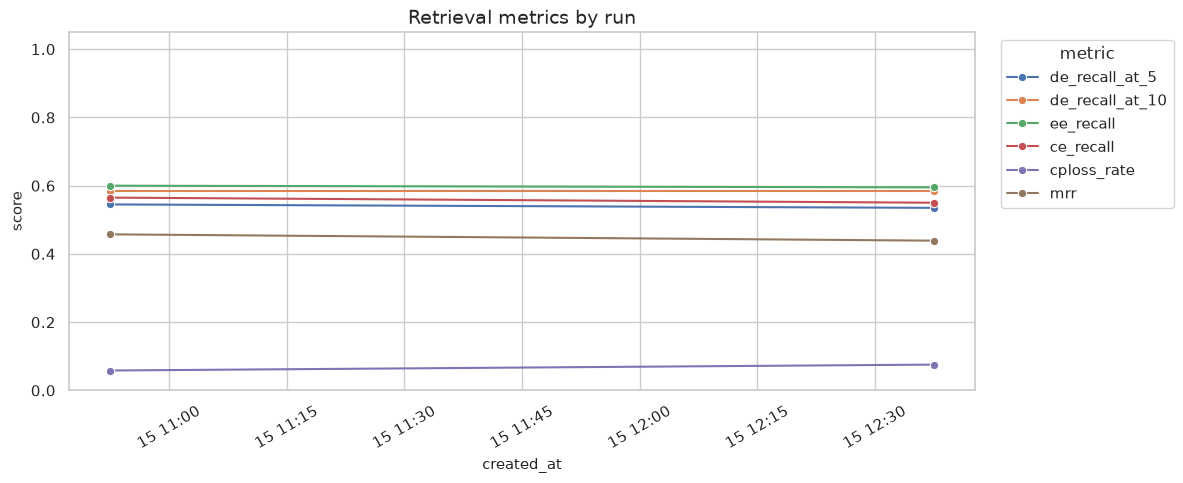

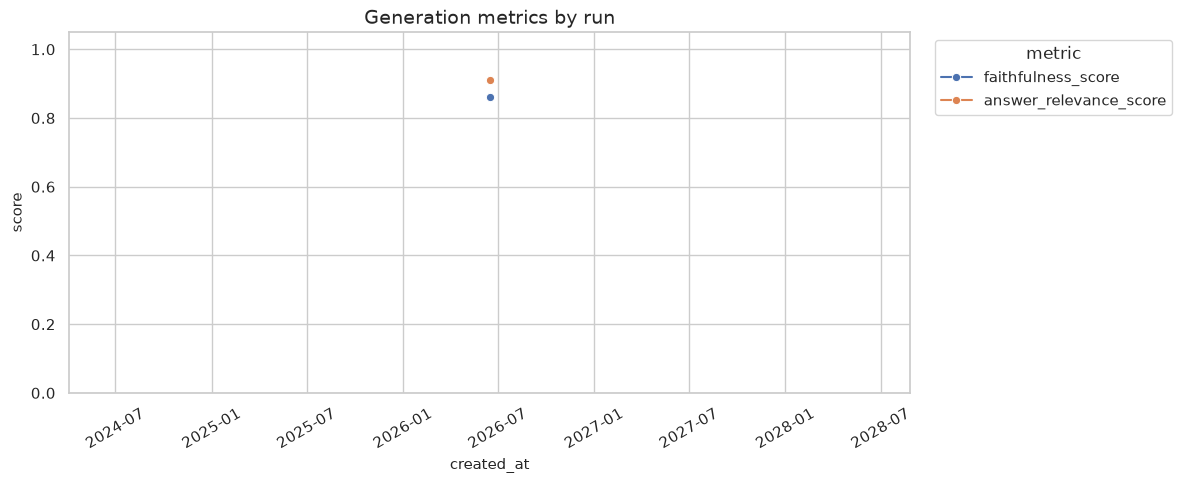

In [ ]:
def plot_metric_history(metrics: list[str], title: str):
    available = [
        m for m in metrics if m in summary_df.columns and summary_df[m].notna().any()
    ]
    if not available:
        display(Markdown(f"Нет данных для графика: **{title}**"))
        return

    plot_df = summary_df[["run_id", "created_at", *available]].melt(
        id_vars=["run_id", "created_at"],
        var_name="metric",
        value_name="value",
    )
    plot_df = plot_df.dropna(subset=["value"])

    plt.figure(figsize=(12, 5))
    ax = sns.lineplot(data=plot_df, x="created_at", y="value", hue="metric", marker="o")
    ax.set_title(title)
    ax.set_xlabel("created_at")
    ax.set_ylabel("score")
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="x", rotation=30)
    ax.legend(title="metric", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
    plt.close()


plot_metric_history(RETRIEVAL_METRICS, "Retrieval metrics by run")
plot_metric_history(GENERATION_METRICS, "Generation metrics by run")

## 2. Retrieval funnel
> **evidence** - эталнный фрагмент-основание, на основе которого формируется ответ на вопрос

Показывает, где именно теряется evidence: прямой поиск, расширение ссылок или упаковка контекста.

`de_recall_at_5` - доля вопросов, где эталонный evidence найден в top-5 прямого поиска.  
`de_recall_at_10` - доля вопросов, где эталонный evidence найден в top-10 прямого поиска.  
`ee_recall` - доля вопросов, где evidence найден после прямого поиска и расширения ссылок/таблиц.  
`ce_recall` - доля вопросов, где evidence попал в финальный контекст для генерации после упаковки.  
`cploss_rate` - доля найденного evidence, потерянного при упаковке контекста.  
`mrr` - средняя обратная позиция первого найденного evidence; чем выше, тем раньше нужный фрагмент в выдаче.  


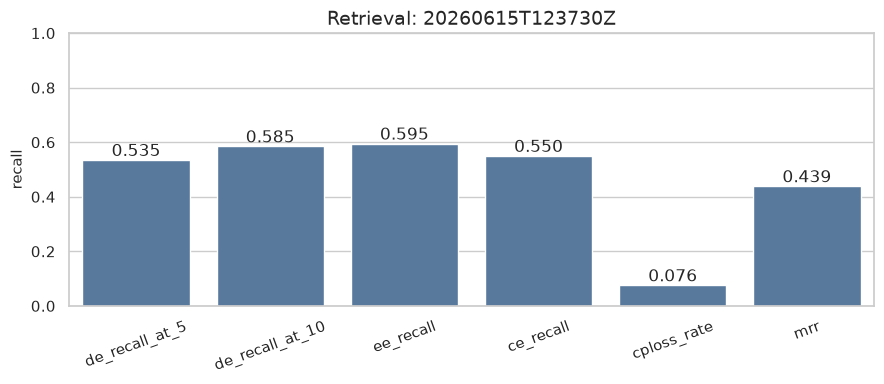

,stage,value
0,de_recall_at_5,0.535000
1,de_recall_at_10,0.585000
2,ee_recall,0.595000
3,ce_recall,0.550000
4,cploss_rate,0.075630
5,mrr,0.438829


In [17]:
funnel_metrics = [
    "de_recall_at_5",
    "de_recall_at_10",
    "ee_recall",
    "ce_recall",
    "cploss_rate",
    "mrr",
]
selected_summary = summary_df[summary_df["run_id"] == SELECTED_RUN_ID].iloc[0]
f_df = pd.DataFrame(
    {
        "stage": funnel_metrics,
        "value": [selected_summary.get(metric) for metric in funnel_metrics],
    }
)

plt.figure(figsize=(9, 4))
ax = sns.barplot(data=f_df, x="stage", y="value", color="#4C78A8")
ax.set_title(f"Retrieval: {SELECTED_RUN_ID}")
ax.set_xlabel("")
ax.set_ylabel("recall")
ax.set_ylim(0, 1)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()
plt.close()

f_df

## 3. Context packing loss и MRR

`cploss_rate` показывает, сколько найденных evidence-фрагментов потерялось при упаковке контекста. `mrr` показывает, насколько высоко ранжируется первый эталонный фрагмент.

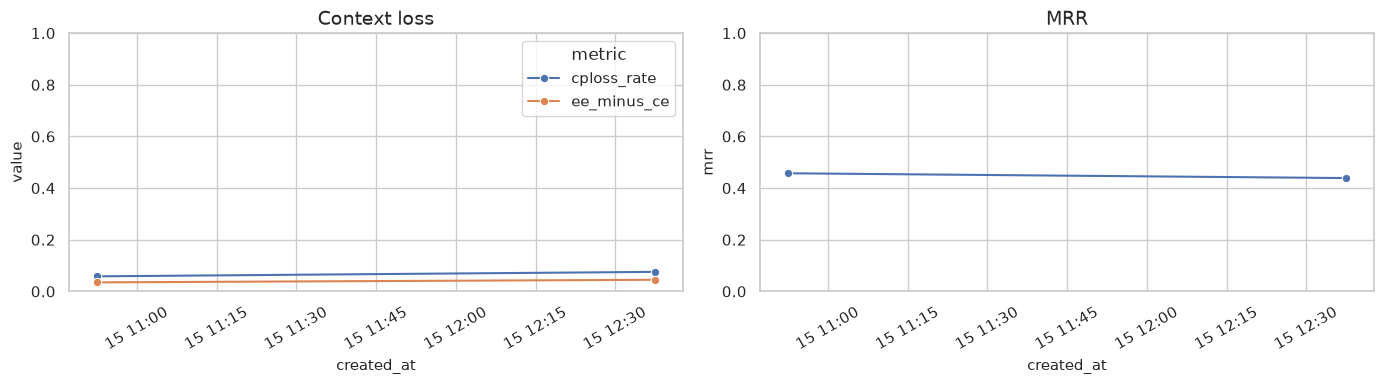

,run_id,created_at,ee_recall,ce_recall,cploss_rate,mrr,ee_minus_ce
0,20260615T105229Z,2026-06-15 10:52:29+00:00,0.600,0.565,0.058333,0.457351,0.035
1,20260615T123730Z,2026-06-15 12:37:30.017631+00:00,0.595,0.550,0.075630,0.438829,0.045


In [ ]:
packing_df = summary_df[
    ["run_id", "created_at", "ee_recall", "ce_recall", "cploss_rate", "mrr"]
].copy()
packing_df["ee_minus_ce"] = packing_df["ee_recall"] - packing_df["ce_recall"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
loss_plot = packing_df.melt(
    id_vars=["run_id", "created_at"],
    value_vars=["cploss_rate", "ee_minus_ce"],
    var_name="metric",
    value_name="value",
).dropna(subset=["value"])
sns.lineplot(
    data=loss_plot, x="created_at", y="value", hue="metric", marker="o", ax=axes[0]
)
axes[0].set_title("Context loss")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=30)

sns.lineplot(data=packing_df, x="created_at", y="mrr", marker="o", ax=axes[1])
axes[1].set_title("MRR")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()
plt.close(fig)

packing_df

## 4. Outcome matrix

Классификация каждого вопроса:

- `not_found` — evidence не найден даже после expansion;
- `found_by_search` — найден прямым поиском и попал в контекст;
- `found_by_expansion` — найден только через расширение ссылок;
- `lost_in_context` — найден до упаковки, но потерян в итоговом контексте.

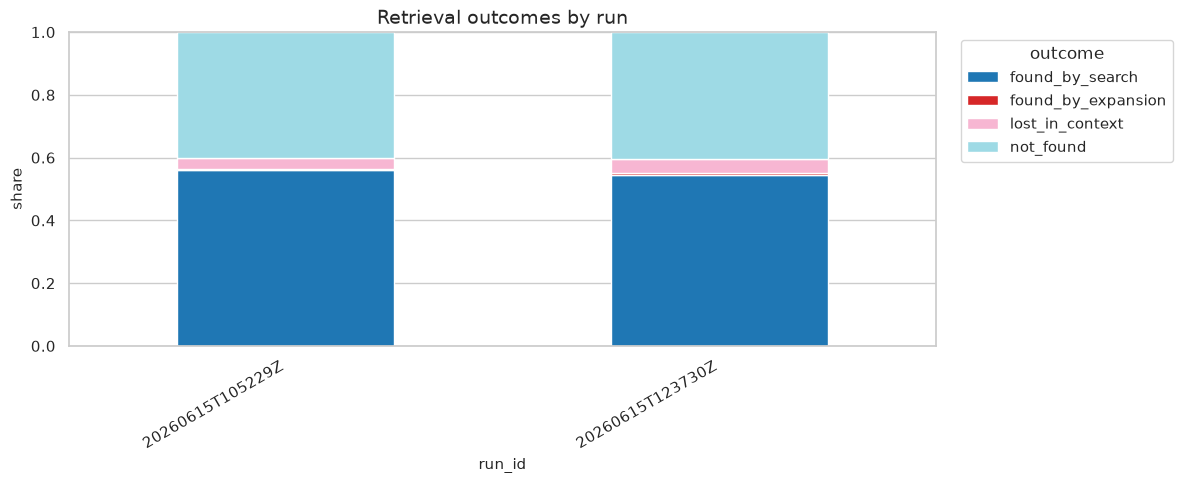

,run_id,outcome,count,share
0,20260615T105229Z,found_by_expansion,1,0.005
1,20260615T105229Z,found_by_search,112,0.560
2,20260615T105229Z,lost_in_context,7,0.035
3,20260615T105229Z,not_found,80,0.400
4,20260615T123730Z,found_by_expansion,1,0.005
5,20260615T123730Z,found_by_search,109,0.545
6,20260615T123730Z,lost_in_context,9,0.045
7,20260615T123730Z,not_found,81,0.405


In [ ]:
outcome_counts = (
    all_question_df.groupby(["run_id", "outcome"]).size().rename("count").reset_index()
)
outcome_counts["share"] = outcome_counts["count"] / outcome_counts.groupby("run_id")[
    "count"
].transform("sum")

pivot = outcome_counts.pivot(index="run_id", columns="outcome", values="share").fillna(0)
order = ["found_by_search", "found_by_expansion", "lost_in_context", "not_found", "other"]
pivot = pivot[[c for c in order if c in pivot.columns]]

ax = pivot.plot(kind="bar", stacked=True, figsize=(12, 5), colormap="tab20")
ax.set_title("Retrieval outcomes by run")
ax.set_xlabel("run_id")
ax.set_ylabel("share")
ax.set_ylim(0, 1)
ax.legend(title="outcome", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
plt.close()

outcome_counts.sort_values(["run_id", "outcome"])

## 5. Метрики по дисциплинам

Префикс `question_id` используется как дисциплина: `АР`, `АС`, `КЖ`.

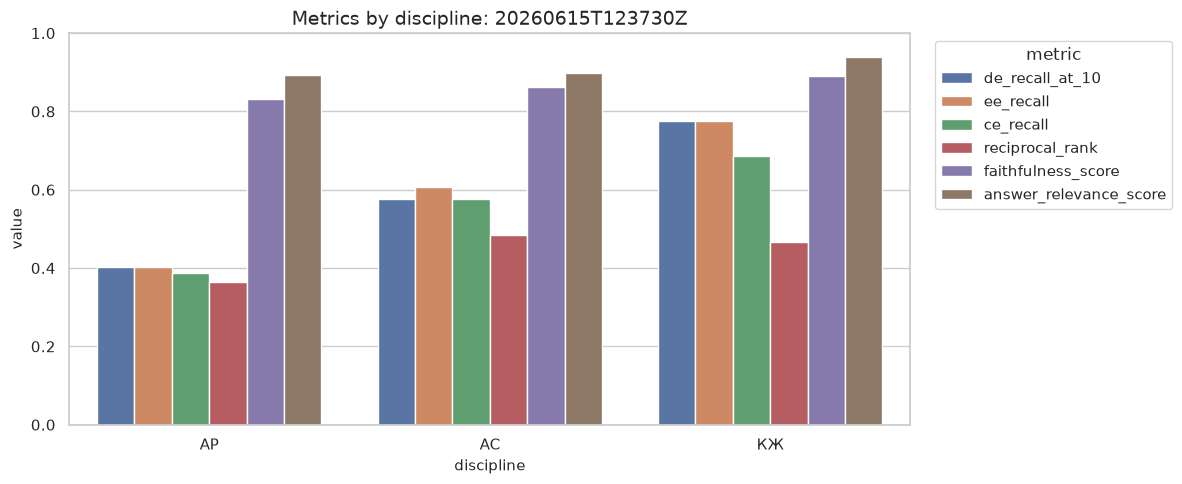

,discipline,de_recall_at_10,ee_recall,ce_recall,reciprocal_rank,faithfulness_score,answer_relevance_score
0,АР,0.402985,0.402985,0.388060,0.365316,0.832031,0.893750
1,АС,0.575758,0.606061,0.575758,0.485269,0.862281,0.897544
2,КЖ,0.776119,0.776119,0.686567,0.466596,0.891406,0.939531


In [ ]:
discipline_metrics = [
    "de_recall_at_10",
    "ee_recall",
    "ce_recall",
    "reciprocal_rank",
    "faithfulness_score",
    "answer_relevance_score",
]
available = [
    m
    for m in discipline_metrics
    if m in question_df.columns and question_df[m].notna().any()
]

discipline_df = question_df.groupby("discipline")[available].mean().reset_index()
plot_df = discipline_df.melt(id_vars="discipline", var_name="metric", value_name="value")

if not plot_df.empty:
    plt.figure(figsize=(12, 5))
    ax = sns.barplot(data=plot_df, x="discipline", y="value", hue="metric")
    ax.set_title(f"Metrics by discipline: {SELECTED_RUN_ID}")
    ax.set_ylim(0, 1)
    ax.legend(title="metric", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
    plt.close()

discipline_df

## 6. Faithfulness vs relevance

Диаграмма помогает найти ответы, которые выглядят релевантными, но плохо подтверждены контекстом.

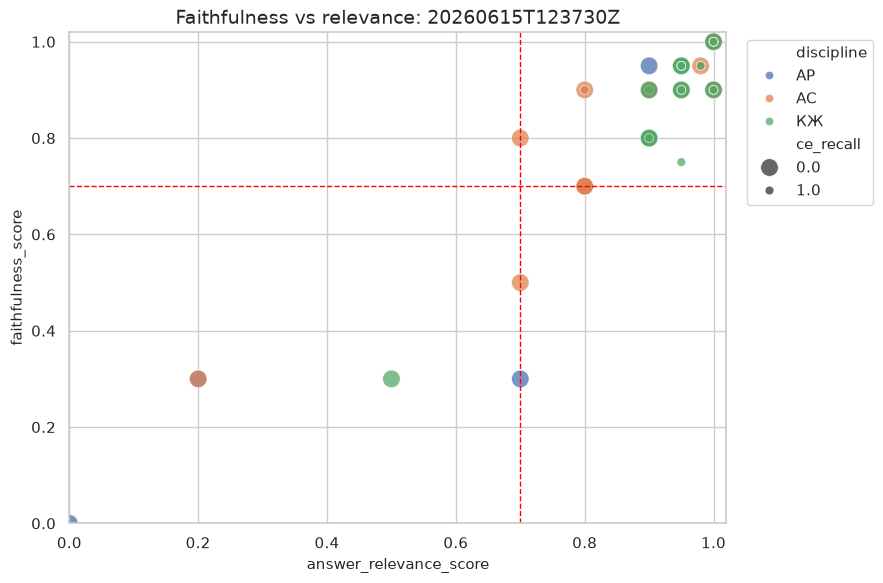

In [ ]:
scatter_cols = ["faithfulness_score", "answer_relevance_score"]
if (
    all(col in question_df.columns for col in scatter_cols)
    and question_df[scatter_cols].notna().any().any()
):
    scatter_df = question_df.dropna(subset=scatter_cols, how="any")
    plt.figure(figsize=(9, 6))
    ax = sns.scatterplot(
        data=scatter_df,
        x="answer_relevance_score",
        y="faithfulness_score",
        hue="discipline",
        size="ce_recall",
        sizes=(40, 160),
        alpha=0.75,
    )
    ax.axhline(0.7, color="red", linestyle="--", linewidth=1)
    ax.axvline(0.7, color="red", linestyle="--", linewidth=1)
    ax.set_title(f"Faithfulness vs relevance: {SELECTED_RUN_ID}")
    ax.set_xlim(0, 1.02)
    ax.set_ylim(0, 1.02)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
    plt.close()
else:
    display(Markdown("Generation-метрик для выбранного запуска нет."))

## 7. Latency breakdown

Время по этапам pipeline. Полезно для сравнения качества с ценой запуска.

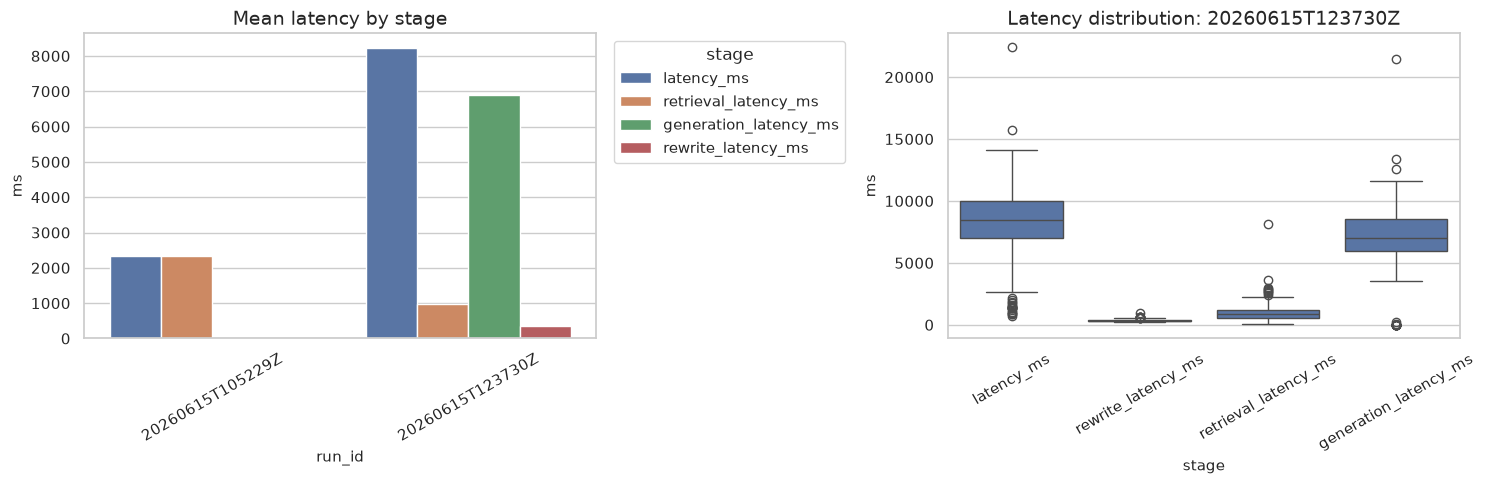

count  unique    top  freq
run_id           stage                                            
20260615T105229Z latency_ms               200     195    248     3
                 retrieval_latency_ms     200     194    769     2
20260615T123730Z generation_latency_ms    200     188     25     7
                 latency_ms               200     200  15700     1
                 retrieval_latency_ms     200     191    973     2
                 rewrite_latency_ms       200     153    268     4

In [ ]:
latency_cols = [c for c in TIMING_COLUMNS if c in all_question_df.columns]
latency_long = (
    all_question_df[["run_id", "question_id", *latency_cols]]
    .melt(
        id_vars=["run_id", "question_id"],
        var_name="stage",
        value_name="ms",
    )
    .dropna(subset=["ms"])
)

if not latency_long.empty:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    mean_latency = latency_long.groupby(["run_id", "stage"])["ms"].mean().reset_index()
    sns.barplot(data=mean_latency, x="run_id", y="ms", hue="stage", ax=axes[0])
    axes[0].set_title("Mean latency by stage")
    axes[0].tick_params(axis="x", rotation=30)
    axes[0].legend(title="stage", bbox_to_anchor=(1.02, 1), loc="upper left")

    selected_latency = latency_long[latency_long["run_id"] == SELECTED_RUN_ID]
    sns.boxplot(data=selected_latency, x="stage", y="ms", ax=axes[1])
    axes[1].set_title(f"Latency distribution: {SELECTED_RUN_ID}")
    axes[1].tick_params(axis="x", rotation=30)

    plt.tight_layout()
    plt.show()
    plt.close(fig)

latency_long.groupby(["run_id", "stage"])["ms"].describe().round(2)

## 8. Search mode / config comparison

Агрегация по ключевым настройкам конфига. Пригодится, когда появятся запуски `dense`, `sparse`, `hybrid`, разные `top_k`, `prefetch_k`, `expand_refs`.

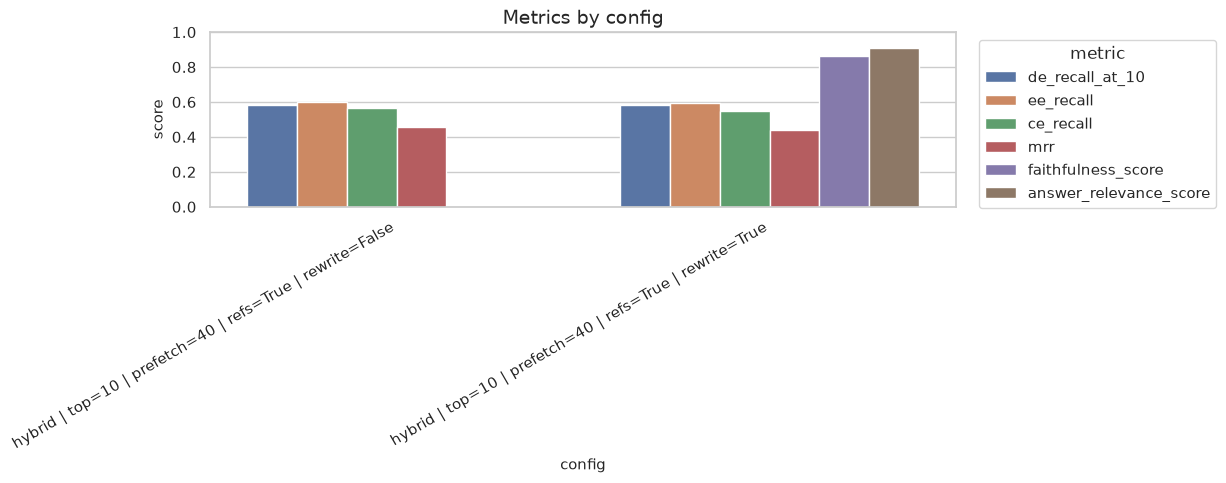

,run_id,config.search_mode,config.top_k,config.prefetch_k,config.expand_refs,config.ref_depth,config.use_rewriter,de_recall_at_10,ee_recall,ce_recall,mrr,faithfulness_score,answer_relevance_score,config_label
0,20260615T105229Z,hybrid,10,40,True,1,False,0.585,0.600,0.565,0.457351,NaN,NaN,hybrid | top=10 | prefetch=40 | refs=True | rewrite=False
1,20260615T123730Z,hybrid,10,40,True,1,True,0.585,0.595,0.550,0.438829,0.861892,0.910757,hybrid | top=10 | prefetch=40 | refs=True | rewrite=True


In [ ]:
config_cols = [
    "config.search_mode",
    "config.top_k",
    "config.prefetch_k",
    "config.expand_refs",
    "config.ref_depth",
    "config.use_rewriter",
]
metric_cols = [
    c
    for c in [
        "de_recall_at_10",
        "ee_recall",
        "ce_recall",
        "mrr",
        "faithfulness_score",
        "answer_relevance_score",
    ]
    if c in summary_df.columns
]
comparison_df = summary_df[["run_id", *config_cols, *metric_cols]].copy()
comparison_df["config_label"] = comparison_df.apply(
    lambda row: (
        f"{row['config.search_mode']} | top={row['config.top_k']} | "
        f"prefetch={row['config.prefetch_k']} | refs={row['config.expand_refs']} | "
        f"rewrite={row['config.use_rewriter']}"
    ),
    axis=1,
)

plot_df = comparison_df.melt(
    id_vars=["run_id", "config_label"],
    value_vars=metric_cols,
    var_name="metric",
    value_name="value",
).dropna(subset=["value"])

if not plot_df.empty:
    plt.figure(figsize=(12, 5))
    ax = sns.barplot(data=plot_df, x="config_label", y="value", hue="metric")
    ax.set_title("Metrics by config")
    ax.set_xlabel("config")
    ax.set_ylabel("score")
    ax.set_ylim(0, 1)
    ax.legend(title="metric", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()
    plt.close()

comparison_df

## 9. Worst cases

Таблицы для ручного разбора. Начинать стоит с вопросов, где evidence не попал в контекст, низкий MRR или низкая faithfulness.

In [ ]:
base_cols = [
    "question_id",
    "discipline",
    "question",
    "outcome",
    "de_recall_at_10",
    "ee_recall",
    "ce_recall",
    "reciprocal_rank",
    "faithfulness_score",
    "answer_relevance_score",
    "latency_ms",
    "first_doc",
]
base_cols = [c for c in base_cols if c in question_df.columns]

retrieval_worst = question_df.sort_values(
    by=["ce_recall", "ee_recall", "de_recall_at_10", "reciprocal_rank"],
    ascending=[True, True, True, True],
)[base_cols].head(20)

display(Markdown("### Worst retrieval cases"))
display(retrieval_worst)

if (
    "faithfulness_score" in question_df.columns
    and question_df["faithfulness_score"].notna().any()
):
    generation_worst = question_df.sort_values(
        by=["faithfulness_score", "answer_relevance_score"],
        ascending=[True, True],
    )[base_cols + ["answer"]].head(20)
    display(Markdown("### Worst generation cases"))
    display(generation_worst)
else:
    display(Markdown("Generation-метрик для выбранного запуска нет."))

### Worst retrieval cases

,question_id,discipline,question,outcome,de_recall_at_10,ee_recall,ce_recall,reciprocal_rank,faithfulness_score,answer_relevance_score,latency_ms,first_doc
0,АР-001,АР,"Какие покрытия пола подходят при средней интенсивности воздействия воды, минеральных масел и органических растворителей?",not_found,0.0,0.0,0.0,0.0,0.80,0.90,15700,СП 71.13330.2017 Изоляционные и отделочные покрытия. Актуализированная редакция.md
4,АР-005,АР,Что зафиксировать при контроле укладки армирующей сетки фасадной штукатурной системы?,not_found,0.0,0.0,0.0,0.0,0.80,0.90,11258,"СП 45.13330.2017 Земляные сооружения, основания и фундаменты. Актуализированная редакция СНиП..._Текст.md"
6,АР-007,АР,Какие дополнительные нагрузки учесть при расчете конструкций жилого дома со встроенными помещениями?,not_found,0.0,0.0,0.0,0.0,0.80,0.90,9684,СП 20.13330.2016 Нагрузки и воздействия. Актуализированная редакция СНиП 2.01.07-85 (с Изменениями..._Текст.md
7,АР-008,АР,По каким нормам проектировать внутренний противопожарный водопровод многоквартирного дома?,not_found,0.0,0.0,0.0,0.0,0.95,0.95,11608,СП 158.13330.2014 Здания и помещения медицинских организаций. Правила проектирования (с Изменениями..._Текст.md
8,АР-009,АР,Из каких материалов можно сделать вертикальный шумозащитный экран?,not_found,0.0,0.0,0.0,0.0,0.80,0.90,8454,СП 71.13330.2017 Изоляционные и отделочные покрытия. Актуализированная редакция.md
9,АР-010,АР,Из каких материалов допускается делать каркас навесного фасада и крепления облицовки?,not_found,0.0,0.0,0.0,0.0,0.70,0.80,8250,СП 2.13130.2020 Системы противопожарной защиты. Обеспечение огнестойкости объектов защиты.md
10,АР-011,АР,Какие шумовые характеристики оборудования запросить у производителя для акустического расчета?,not_found,0.0,0.0,0.0,0.0,0.70,0.80,6920,ГОСТ 32314-2023 (EN 131622012) Изделия из минеральной ваты теплоизоляционные промышленного.md
14,АР-015,АР,Какие защитные и эксплуатационные слои можно предусмотреть на рулонной или мастичной кровле?,not_found,0.0,0.0,0.0,0.0,0.80,0.90,8185,СП 17.13330.2017 Кровли. Актуализированная редакция.md
16,АР-017,АР,"Что изменить в расчете высоты сжатой зоны фибробетонного подстилающего слоя, если содержание фибры ниже минимального?",not_found,0.0,0.0,0.0,0.0,0.80,0.90,9847,СП 435.1325800.2018 Конструкции бетонные и железобетонные монолитные. Правила производства и..._Текст.md
18,АР-019,АР,Как подобрать табличный коэффициент для расчета подстилающего слоя пола при нагрузке сложного вида?,not_found,0.0,0.0,0.0,0.0,NaN,NaN,2011,СП 15.13330.2020 Каменные и армокаменные конструкции СНиП II-2281 (с Изменением N 1)_Текст.md


### Worst generation cases

,question_id,discipline,question,outcome,de_recall_at_10,ee_recall,ce_recall,reciprocal_rank,faithfulness_score,answer_relevance_score,latency_ms,first_doc,answer
30,АР-031,АР,Как рассчитывать шум в помещении от нескольких воздухораспределительных устройств?,not_found,0.0,0.0,0.0,0.0,0.00,0.00,9007,"СП 60.13330.2020 Отопление, вентиляция и кондиционирование воздуха СНиП 41-01-2003 (с Поправкой, с..._Текст.md","#### Ответ \n1. В контексте не указано, как рассчитывать уровень шума в помещении от нескольких воздухораспределительных устройств. \n#### Что удалось найти \n- В тексте не указано, как рассчитывать уровень шума в..."
53,АР-054,АР,Насколько земляной шумозащитный вал должен быть выше эквивалентного вертикального экрана?,not_found,0.0,0.0,0.0,0.0,0.30,0.20,8319,ГОСТ Р 59789-2021 (МЭК 62305-32010) Молниезащита. Часть 3. Защита зданий и сооружений.md,"#### Ответ \n<1–3 предложения: прямой ответ> \nВ нормативных документах не указано, насколько земляной шумозащитный вал должен быть выше эквивалентного вертикального экрана. \n\n#### Что удалось найти \n- В текст..."
96,АС-030,АС,"На отсеки какой площади разделять насосную, перекачивающую горючий продукт с температурой 250 °C и выше?",not_found,0.0,0.0,0.0,0.0,0.30,0.20,7957,СП 89.13330.2016 Котельные установки. Актуализированная редакция СНиП II-35-76 (с Изменением N 1)_Текст.md,"#### Ответ \n1. В контексте не указаны конкретные требования к площади отсеков, разделяющих насосную установку, перекачивающую горючие продукты при температуре 250 °C и выше. \n#### Что удалось найти \n- В тексте ..."
184,КЖ-052,КЖ,Как корректировать коэффициент условий работы арматуры при увеличении диаметра стержней?,lost_in_context,1.0,1.0,0.0,0.1,0.30,0.50,8885,ГОСТ 14098-2014 Соединения сварные арматуры и закладных изделий железобетонных конструкций. Типы.md,"#### Ответ \n<Короткий вывод: В документах не указано, как корректировать коэффициент условий работы арматуры при увеличении диаметра стержней.> \n\n#### Что удалось найти \n- В разделе ""Соединения ненапрягаемой а..."
50,АР-051,АР,Какова критическая плотность теплового потока для древесно-стружечной плиты плотностью 417 кг/м³?,not_found,0.0,0.0,0.0,0.0,0.30,0.70,9233,СП 70.13330.2012 Несущие и ограждающие конструкции. Актуализированная редакция.md,#### Ответ\n<1–3 предложения: прямой ответ> \nВ контексте не найдено конкретное значение критической плотности теплового потока для древесно-стружечной плиты плотностью 417 кг/м³.\n\n#### Что удалось найти \n- В та...
71,АС-005,АС,Минимальное расстояние между группами автомобилей с горюче-смазочными материалами на открытой площадке?,not_found,0.0,0.0,0.0,0.0,0.50,0.70,8733,СП 89.13330.2016 Котельные установки. Актуализированная редакция СНиП II-35-76 (с Изменением N 1)_Текст.md,#### Ответ \n1. Минимальное расстояние между группами автомобилей с горюче-смазочными материалами на открытой площадке не указано в прямом виде в переданном контексте. Однако в разделе 7.3.2 СП 113.13330.2023 указан...
9,АР-010,АР,Из каких материалов допускается делать каркас навесного фасада и крепления облицовки?,not_found,0.0,0.0,0.0,0.0,0.70,0.80,8250,СП 2.13130.2020 Системы противопожарной защиты. Обеспечение огнестойкости объектов защиты.md,"#### Ответ \n<1–3 предложения: прямой ответ> \nДля каркаса навесного фасада и крепления облицовки допускаются материалы, указанные в ГОСТ 33739–2016, а также строительные материалы, предусмотренные в ГОСТ 30893–99...."
10,АР-011,АР,Какие шумовые характеристики оборудования запросить у производителя для акустического расчета?,not_found,0.0,0.0,0.0,0.0,0.70,0.80,6920,ГОСТ 32314-2023 (EN 131622012) Изделия из минеральной ваты теплоизоляционные промышленного.md,"#### Ответ \n1–3 предложения: Для акустического расчета следует запросить у производителя допустимые уровни шума и вибраций, а также коэффициенты передачи и параметры изоляции оборудования, указанные в СП 51.13330. ..."
26,АР-027,АР,Как проверить прочность сечения кронштейна навесного фасада у консоли?,not_found,0.0,0.0,0.0,0.

## 10. Инспектор вопроса

`QUESTION_ID` меняется

In [ ]:
QUESTION_ID = question_df.sort_values("ce_recall").iloc[109]["question_id"]


def inspect_question(question_id: str, run_id: str = SELECTED_RUN_ID):
    records = question_records(run_id)
    record = next(
        (item for item in records if item.get("question_id") == question_id), None
    )
    if record is None:
        raise ValueError(f"Question not found: {question_id}")

    pipeline = record.get("pipeline_result", {})
    retrieved = pipeline.get("retrieved", [])
    rows = []
    for rank, chunk in enumerate(retrieved, start=1):
        rows.append(
            {
                "rank": rank,
                "score": chunk.get("score"),
                "filename": chunk.get("filename"),
                "section_path": chunk.get("section_path"),
                "leaf_heading": chunk.get("leaf_heading"),
                "chunk_id": chunk.get("id"),
                "text": chunk.get("text"),
            }
        )

    display(Markdown(f"### {question_id}"))
    display(Markdown(f"**Question:** {pipeline.get('question')}"))

    if pipeline.get("was_rewritten"):
        display(Markdown(f"**Effective question:** {pipeline.get('effective_question')}"))

    display(Markdown("**Retrieval metrics**"))
    display(pd.DataFrame([record.get("retrieval_metrics", {})]))
    display(Markdown("**Generation metrics**"))
    display(pd.DataFrame([record.get("generation_metrics", {})]))
    display(Markdown("**Answer**"))
    display(Markdown(pipeline.get("answer") or "Ответ не генерировался."))
    display(Markdown("**Retrieved chunks**"))
    display(pd.DataFrame(rows))


inspect_question(QUESTION_ID)

### АР-053

**Question:** Что должна обеспечивать автоматизация инженерных систем автостоянки?

**Effective question:** Автоматизация инженерных систем автостоянки должна обеспечивать функционирование и управление техническими процессами.

**Retrieval metrics**

,de_recall_at_5,de_recall_at_10,ee_recall,ce_recall,cploss_rate,rrs_rate,reciprocal_rank
0,1.0,1.0,1.0,1.0,0.0,None,1.0


...

,faithfulness_score,answer_relevance_score,unsupported_claims,explanation,error
0,0.8,0.9,[],"Ответ частично соответствует контексту, так как охватывает основные элементы автоматизации инженерных систем, такие как мониторинг, управление, диспетчеризация и сигнализация. Однако, в ответе не упоминается необходи...",None


**Answer**

#### Ответ  
1–3 предложения: Автоматизация инженерных систем автостоянки должна обеспечивать мониторинг, управление и диспетчеризацию оборудования, а также автоматическое поддержание заданных параметров и сигнализацию о отклонениях.  

#### Что удалось найти  
- Система автоматизации и диспетчеризации инженерного оборудования должна обеспечивать мониторинг, управление и диспетчеризацию оборудования инженерных систем [1].  
- Система автоматизации должна обеспечивать программное управление инженерными системами, автоматическое поддержание заданных значений параметров, защиту от аварийных ситуаций, технологическую и аварийную сигнализацию [3].  
- Система диспетчеризации должна обеспечивать сбор данных о состоянии оборудования, визуальное отображение процессов, централизованный контроль и дистанционное управление инженерными системами [3].  

#### Основание  
| Документ | Раздел |  
|---------|-------|  
| СП 113.13330.2023 | 8.5.7 Система автоматизации и диспетчеризации инженерного оборудования |  
| СП 113.13330.2023 | 8.1.6 Управление инженерными системами |  
| СП 158.13330.2014 | 7.3.2 Автоматизация и диспетчеризация инженерных систем |  
| СП 158.13330.2014 | 7.3.3 Система диспетчеризации инженерных систем |

**Retrieved chunks**

,rank,score,filename,section_path,leaf_heading,chunk_id,text
0,1,16.086771,"СП 113.13330.2023 Стоянки автомобилей_с Изм. № 1,2,3.md",СТОЯНКИ АВТОМОБИЛЕЙ Parkings > 8.5.7 Система автоматизации и диспетчеризации инженерного оборудования,8.5.7 Система автоматизации и диспетчеризации инженерного оборудования,f81281db-9e29-5960-8b30-3788d9c56120,"Системой автоматизации и диспетчеризации инженерного оборудования должны быть обеспечены: мониторинг, управление и диспетчеризация оборудования инженерных систем.\nВ стоянках автомобилей закрытого типа следует предус..."
1,2,14.052619,"СП 113.13330.2023 Стоянки автомобилей_с Изм. № 1,2,3.md",СТОЯНКИ АВТОМОБИЛЕЙ Parkings > 8.1 Общие требования,8.1 Общие требования,6dfc5456-e337-54ed-8daa-2568d6801b74,"8.1.6 Управление инженерными системами допускается осуществлять из удаленной диспетчерской в соответствии с техническими условиями эксплуатирующей организации.\nВ стоянках автомобилей, пристроенных или встроенных в з..."
2,3,13.717399,СП 158.13330.2014 Здания и помещения медицинских организаций. Правила проектирования (с Изменениями..._Текст.md,ЗДАНИЯ И ПОМЕЩЕНИЯ МЕДИЦИНСКИХ ОРГАНИЗАЦИЙ ПРАВИЛА ПРОЕКТИРОВАНИЯ Buildings and rooms for health care facilities. Design rules > 7.3 Автоматизация и диспетчеризация инженерных систем,7.3 Автоматизация и диспетчеризация инженерных систем,b90fa0fb-d9f6-5bc6-a36f-76a6d9d8b189,7.3.1 В медицинских организациях автоматизации и диспетчеризации подлежат следующие инженерные системы:\nлечебного газоснабжения;\nотопления и теплоснабжения;\nводоснабжения и канализации;\nвентиляции и кондициониров...
3,4,13.583454,"СП 113.13330.2023 Стоянки автомобилей_с Изм. № 1,2,3.md",СТОЯНКИ АВТОМОБИЛЕЙ Parkings > 8.5.5 Система контроля и управления доступом,8.5.5 Система контроля и управления доступом,9f97c3ec-0c9c-5682-bc3c-f4fccc97840f,Система контроля и управления доступом должна обеспечивать предотвращение несанкционированного доступа на территорию стоянки автомобилей. Системой контроля и управления доступа в соответствии с заданием на проектиров...
4,5,13.375332,"СП 113.13330.2023 Стоянки автомобилей_с Изм. № 1,2,3.md",СТОЯНКИ АВТОМОБИЛЕЙ Parkings > 8.5.1 Общие положения,8.5.1 Общие положения,b74345ba-4705-5b4f-b5f0-1cf006e857bc,"Системы связи и сигнализации стоянок автомобилей выполняют в соответствии с СП 3.13130, СП 134.13330 и заданием на проектирование.\nПостроение систем связи и сигнализации следует предусматривать с учетом деления на п..."
5,6,13.189011,"СП 113.13330.2023 Стоянки автомобилей_с Изм. № 1,2,3.md",СТОЯНКИ АВТОМОБИЛЕЙ Parkings > 8.1 Общие требования,8.1 Общие требования,6690b1d1-eee5-54e9-8b5a-70a541720ea6,"8.1.1 Сети инженерно-технического обеспечения стоянок автомобилей и их инженерное оборудование следует предусматривать с учетом СП 30.13330, сП 32.13330, сП 60.13330, СП 104.13330, CP 3.13130, CП 6.13130, CP 7.13130,..."
6,7,12.757956,"СП 113.13330.2023 Стоянки автомобилей_с Изм. № 1,2,3.md",СТОЯНКИ АВТОМОБИЛЕЙ Parkings > 7.7 Механизированные стоянки автомобилей,7.7 Механизированные стоянки автомобилей,b7593064-406a-5b03-ac5a-f4292234220d,"7.7.1 Механизированные стоянки автомобилей с учетом оборудования автоматическими механизированными парковочными системами выполняют: наземными открытого типа, наземными закрытого типа, подземными, комбинированными и ..."
7,8,12.634738,"СП 113.13330.2023 Стоянки автомобилей_с Изм. № 1,2,3.md",СТОЯНКИ АВТОМОБИЛЕЙ Parkings > 8.5.2 Система охранной сигнализации,8.5.2 Система охранной сигнализации,787e52ef-d2fc-502f-9814-6e3e57addc89,"Системой охранной сигнализации по заданию на проектирование должно быть обеспечено обнаружение несанкционированного доступа в охраняемые зоны, помещения стоянки автомобилей. Сигнал о срабатывании средств обнаружения ..."
8,9,12.517364,ГОСТ Р 59789-2021 (МЭК 62305-32010) Молниезащита. Часть 3. Защита зданий и сооружений.md,Дополнительная информация для систем молниезащиты взрывоопасных сооружений > D.6.4 Требования к проверкам,D.6.4 Требования к проверкам,c6bb38fe-dd2e-5483-9594-4d386dfb16d